# The 9-Qubit Shor Code in Julia

In this notebook, the Shor code is investigated and benchmarked using the julia language and QuantumClifford.jl package. The general program here will be similar to what was presented using qiskit in the other notebooks: We will first walk through linear repetition codes and use them as a case study to demonstrate how errors can be detected and decoded, then we will move on to implementing the Shor code fully. 


## Imports
First, we load our packadges:

In [1]:
using CairoMakie      # For plotting (incluing tableau diagrams)
using Quantikz        # For drawing quantum circuits
using QuantumClifford # For quantum Clifford circuits
using QuantumClifford.ECC: parity_checks, Steane7, Shor9, naive_syndrome_circuit

## Repetition Code

To begin, we will work through an example using a repetition code.

In order to assess whether an error has occurred in our qubits, we will use a parity check matrix. This is one level of abstraction higher than the direct gate operations we used in the qiskit section of this repo, but accomplishes the same task of searching for a single flipped qubit in our repetition code. In this section I am going to refer to the basic units of information in this section as “qubits” undergoing potential X errors, but it may be best to in fact think of them as being bits undergoing classical bit-flip errors. Once we implement the Shor code proper, the quantum nature of the qubit will come back into play. 


In the case of a straightforward repetititon code with $|0_L \rangle = |000\rangle $ and $|1_L \rangle = |111\rangle $, our parity check matrix takes the following form:

In [3]:
H_rep = [1 1 0; 0 1 1]

2×3 Matrix{Int64}:
 1  1  0
 0  1  1

Where the "_rep" suffix is being used to mean "repetition." 

Let's imagine the incoming initial state is known to be $|1_L\rangle$:

In [4]:
state_rep = [1 
            1 
            1];

We test this against the parity check matrix, and observe the resulting syndrome state to be 00, no error. 

In [5]:
 ( H_rep * state_rep ) .% 2

2-element Vector{Int64}:
 0
 0

We can also inject some single qubit error by a taking the XOR operation between our state_rep vector and some induced error_rep, and observe how the output syndrome is changed

In [6]:
error_rep = [1
            0
            0];

(H_rep * (state_rep .⊻ error_rep)) .% 2

2-element Vector{Int64}:
 1
 0

Just like before in our qiskit code, a syndrome of 10 means a bitflip error has occurred on the first physical qubit. Similarly, 11 signals a flip on the central qubit, and 01 a flip on the final qubit. 


Note that, also like before in the qiskit code, this implementation is vulnerable to multi-qubit errors. For our purposes we say this is acceptable. Since if the probability of a single qubit error is $p$ then the probability of two errors is $p^2$, which is smaller. Thus, we are always correcting for the most probable error. 



## Correcting Errors


Now that we can identify errors in the repetition code, the next step is to correct them. To do this, we create a simple lookup table that maps syndrome outputs to error correction vectors. This reveals an additional requirement of error correcting codes: That each syndrome be uniquely associated with an error.  There are other, more computationally efficient ways to decode errors as codes become larger, but for our purposes the lookup table will be sufficient. 
 

To construct the lookup table, we simply iterate through single qubit errors and associate them with each possible syndrome output. 

In [7]:
function build_lookup_table(H)
    lookup_table = Dict()
    constraints, bits = size(H) 
    # In the case of no errors
    lookup_table[ zeros(Int, constraints) ] = zeros(Int, bits)
    # In the case of single bit errors
    for bit_to_be_flipped in 1:bits
        # Generate error vector
        error = zeros(Int, bits)
        error[bit_to_be_flipped] = 1
        # Calculate syndrome vector from the error
        syndrome = (H*error) .% 2
        # Store the syndrome for a given error
        lookup_table[syndrome] = error
    end
    lookup_table
end;

In [8]:
rep_table = build_lookup_table(H_rep)

Dict{Any, Any} with 4 entries:
  [0, 0] => [0, 0, 0]
  [1, 1] => [0, 1, 0]
  [1, 0] => [1, 0, 0]
  [0, 1] => [0, 0, 1]

From here, it is simply a matter of applying another XOR operation against the input qubit to correct the error. 

## Monte Carlo Assessment of Error Correction Fidelity 
 
 In order to assess the fidelity of our error correcting code, we will inject random errors and assess what proportion of them are corrected successfully. We will do this by establishing some probability with which single qubit errors occur, running our correcting code, and then determining how many of the random errors were correctly identified. By default, we will run 100,000 shots. 

In [28]:
function evaluate_decoder_monte_carlo(code, p; samples = 100_000)      #As an input, we enter H and our probability of a single qubit X error. 
    lookup_table = build_lookup_table(code)
    constraints, bits = size(code)
    decoded = 0 # this will count the number of correct decodings
    for sample in 1:samples
        error = rand(bits) .< p                          # this randomly generates an error
        syndrome = (code * error) .% 2                      # this applies that error to the system and produces the associated syndrome
        answer = get(lookup_table, syndrome, nothing)    # this decodes the syndrome based on the lookup table
        if answer==error
            decoded += 1                                 # if the error was correctly identified, we count that towards our total
        end
    end
    1- decoded / samples                                 # finally, we simply return the proportion of correctly identified errors. 
end;

#Also, now is a good time to introuce a quick plotting function

function plot_code_performance(error_rates, post_ec_error_rates; title="")
    f = Figure(size=(500,300))
    ax = f[1,1] = Axis(f, xlabel="physical error rate", ylabel="logical error rate", title=title)
    ax.aspect = DataAspect()
    lim = max(error_rates[end],post_ec_error_rates[end])
    lines!([0,lim], [0,lim], label="single bit", color=:black)
    plot!(error_rates, post_ec_error_rates, label="after decoding", color=:black)
    xlims!(0,lim)
    ylims!(0,lim)
    f[1,2] = Legend(f, ax, "Error Rates")
    f
end;

Let’s graph the proportion of decoded errors against a variety of error rates, ranging from $p=0.01$ to $p = 0.8$. 

In [29]:
error_rates = 0.01:0.05:0.8
post_ec_error_rates = [evaluate_decoder_monte_carlo(H_rep,p) for p in error_rates];

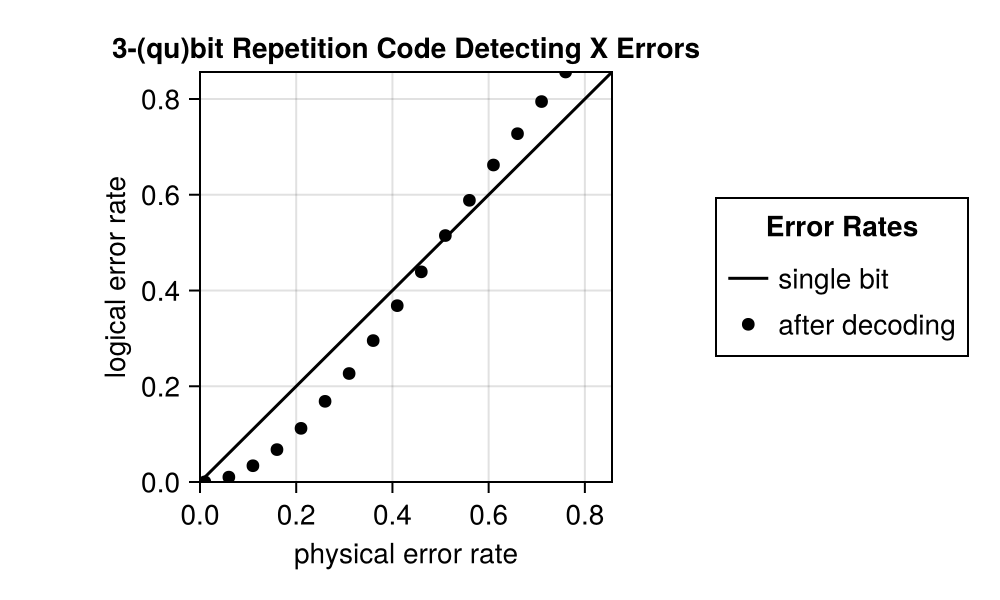

In [30]:
plot_code_performance(error_rates, post_ec_error_rates, title="3-(qu)bit Repetition Code Detecting X Errors")

The diagonal line represents logical error probability against physical qubit error probability. If, after decoding, the black dots fall below the diagonal line then this means a logical qubit error is less probable than a physical qubit error and our decoder is working as intended to reduce the logical qubit error rate. However, if the black dots fall above the line this means that the probability of a logical error is actually worse (after decoding) than the probability of a physical error. Possibly counterintuitively, this means that for certain probabilities of single-qubit error our decoder actually makes the program run *worse*, by increasing the probability of logical qubit error above that of physical qubit error. 

There is a critical point where this occurs, on our graph this happens when the probability of a single physical qubit error is $p \approx 0.5$. As long as a single bit flip error is *less* probable than that, our error correcting code is working to improve the error rate. 

Now that we’ve seen the basic tools at play for the X error acting on a 3-repetition code, it’s time to turn our attention back to the Shor code.  


## The Shor Code

The Shor code already exists within the QuantumClifford Package, and we have already seen how it is built in the connected qiskit notebooks, but for the sake of having this julia exploration serve as a standalone product I will briefly walk through how it is built up once again. 



For this implementation we’ll be concerned with building the parity check matrix for the 9-qubit Shor code. Recalling what was done in previous notebooks, and the shape of the concatenated code, it is clear what this needs to accomplish: 

Firstly, we must identify single qubit X errors in any of our three qubit repetition codes. 
Secondly, we must identify phase errors in any of the three blocks of repetition code. 

Conveniently, we recall that this also protects us from Y errors, since those can be treated as an X and Z type error occurring in sequence ( which we recall from the Pauli algebra $\sigma_z \sigma_x = i \sigma_y$ )

Let’s expand the parity check matrix stored in QuantumClifford, and see the shape it takes:



In [15]:
shor_code = parity_checks(Shor9())

+ XXXXXX___
+ ___XXXXXX
+ ZZ_______
+ _ZZ______
+ ___ZZ____
+ ____ZZ___
+ ______ZZ_
+ _______ZZ


Precisely as expected! From here, though, we run into an interesting issue which we can see if we try to evaluate errors as before.


First, though, we will need to re-write our evaluator function to now induce random Pauli errors, not only bit-flip errors, since we are now working in a regime where the qubits are truly qubits, and not simply effectively-classical bits like before. 

We will also need to slightly adjust our lookup table builder, since now we apply Pauli operators to undo errors – not just bit flips. 


In [16]:
function build_lookup_table(code::Stabilizer)
    lookup_table = Dict()
    constraints, qubits = size(code)
    # In the case of no errors
    lookup_table[ zeros(UInt8, constraints) ] = zero(PauliOperator, qubits)
    # In the case of single bit errors
    for bit_to_be_flipped in 1:qubits
        for error_type in [single_x, single_y, single_z]
            # Generate error
            error = error_type(qubits, bit_to_be_flipped)
            # Calculate syndrome
            # (check which stabilizer rows do not commute with the Pauli error)
            syndrome = comm(error, code)
            # Store syndrome and error pair
            lookup_table[syndrome] = error
        end
    end
    lookup_table
end;

In [23]:
function evaluate_decoder_monte_carlo(code::Stabilizer,p; samples=10_000)
    lookup_table = build_lookup_table(code)
    constraints, qubits = size(code)
    decoded = 0 # Counts correct decodings
    for sample in 1:samples
        # Generate random error
        error = random_pauli(qubits,p,nophase=true)
        # Apply that error to your physical system
        # and get syndrome
        syndrome = comm(error, code)
        # Decode the syndrome
        guess = get(lookup_table,syndrome,nothing)
        # check if you were right
        if guess==error
            decoded += 1
        end
    end
    1 - decoded / samples
    end;

Now that we’ve done that, let’s plot:


  0.159946 seconds (1.80 M allocations: 66.398 MiB, 86.36% compilation time)


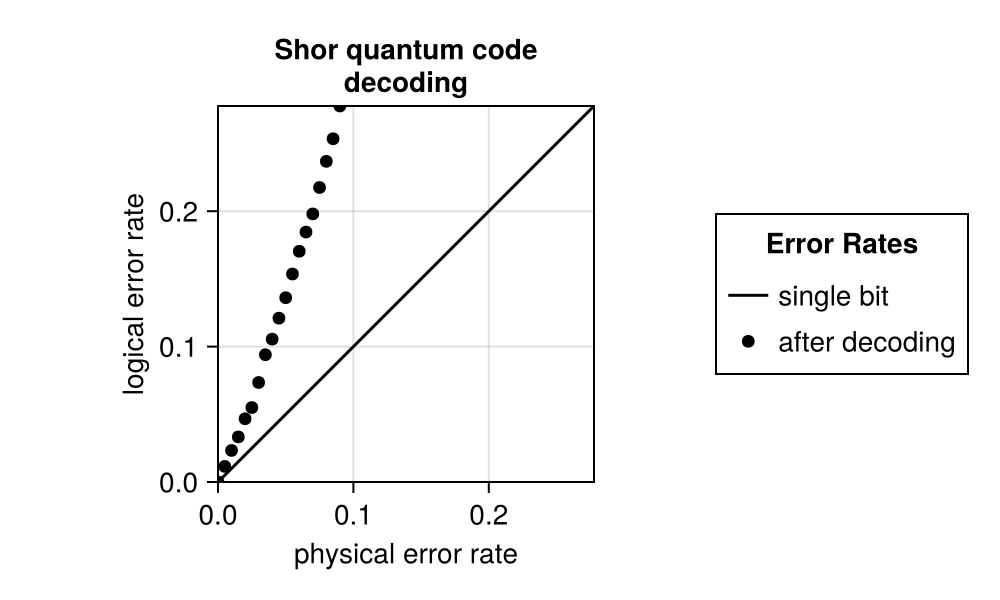

In [24]:
error_rates = 0.000:0.005:0.09
@time post_ec_error_rates = [evaluate_decoder_monte_carlo(shor_code, p) for p in error_rates]
plot_code_performance(error_rates, post_ec_error_rates, title="Shor quantum code\ndecoding")

Egads! This result makes it seem like implementing the Shor code actually made our logical errors *more* probable than physical errors - which, for our implementation, it genuinely did. 

Why would this happen? Let’s look a the lookup table itself for a clue:


In [27]:
shor_table = build_lookup_table(shor_code)

Dict{Any, Any} with 22 entries:
  UInt8[0x01, 0x01, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00] => + _____Y___
  UInt8[0x00, 0x01, 0x00, 0x00, 0x00, 0x00, 0x01, 0x01] => + _______Y_
  UInt8[0x00, 0x01, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00] => + ______Y__
  UInt8[0x01, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00] => + __Z______
  UInt8[0x01, 0x00, 0x01, 0x01, 0x00, 0x00, 0x00, 0x00] => + _Y_______
  UInt8[0x01, 0x01, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00] => + ___Y_____
  UInt8[0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x00] => + __X______
  UInt8[0x01, 0x01, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00] => + _____Z___
  UInt8[0x00, 0x00, 0x00, 0x00, 0x01, 0x01, 0x00, 0x00] => + ____X____
  UInt8[0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x00, 0x00] => + X________
  UInt8[0x00, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00] => + _____X___
  UInt8[0x01, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x00] => + __Y______
  UInt8[0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00] => + ___X_____
  UInt8[0x01, 0x00, 0x01, 0x00, 0x00, 0x00, 0

Aha! So here is the issue. We would expect our lookup to have $3 \times 9 + 1 = 28$ entries, since there are 28 possible single qubit errors that could occur (X, Y, and Z errors on any one of the 9 physical qubits, plus the identity). 

Despite this, our lookup table only has $22$ entries, meaning that some single qubit errors are degenerate in their syndrome outputs. Put another way, different errors lead to the same syndrome and the same logical flips.  

In fact, we knew this already – when a phase error occurs on one of our blocks of repetition code, it doesn’t matter which of the three constituent physical qubits experienced the error – the phase error is picked up by the whole block. This accounts precisely for the 6 fewer entries in the lookup table. 

In principle this isn’t actually a problem, so long as the errors which carry the degeneracy in their syndrome outputs are also corrected by the same correction operation. The reason this manifested the way it did in our code is that it was simply clashing with the way the error correction was being implemented. By modifying the decoder to account for the degeneracy, we can fix the issue we saw earlier where our error correction made things worse:


In [31]:
function evaluate_decoder_monte_carlo(code::Stabilizer,p; samples=10_000)
    lookup_table = build_lookup_table(code)
    constraints, qubits = size(code)
    full_tableau = MixedDestabilizer(code)
    logicals = vcat(logicalxview(full_tableau),logicalzview(full_tableau))
    decoded = 0 # Counts correct decodings
    for sample in 1:samples
        # Generate random pauli error
        error = random_pauli(qubits,p/3,nophase=true)
        # Apply that error to the physical system, and get syndrome
        syndrome = comm(error, code)
        # Decode the syndrome like before from the lookup table
        guess = get(lookup_table,syndrome,nothing)
        # Check if the suggested error correction corrects the error, or if it is equivalent to a logical operation
        if !isnothing(guess) && all(==(0x0), comm(guess*error, code)) && all(==(0x0), comm(guess*error, logicals))
            decoded += 1
        end
    end
    1 - decoded / samples
end;

Regenerating the same plot from before, we see things are now much improved. Just for fun, the plot contains error rates up to $p=1$ 

  0.517469 seconds (36.55 M allocations: 1.161 GiB, 15.98% gc time, 2.46% compilation time)


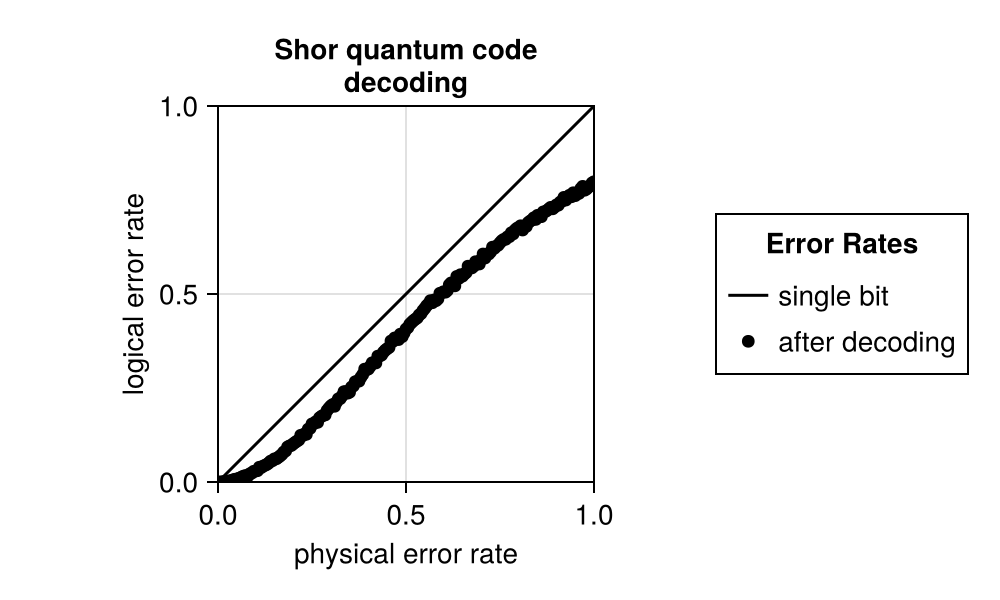

In [34]:
error_rates = 0.000:0.005:1
@time post_ec_error_rates = [evaluate_decoder_monte_carlo(shor_code, p) for p in error_rates]
plot_code_performance(error_rates, post_ec_error_rates, title="Shor quantum code\ndecoding")